In [8]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import math
import tensorflow as tf
import keras
from pathlib import Path 
import datetime
from datetime import timezone
import birja_copy as bc
import mplfinance as mpl

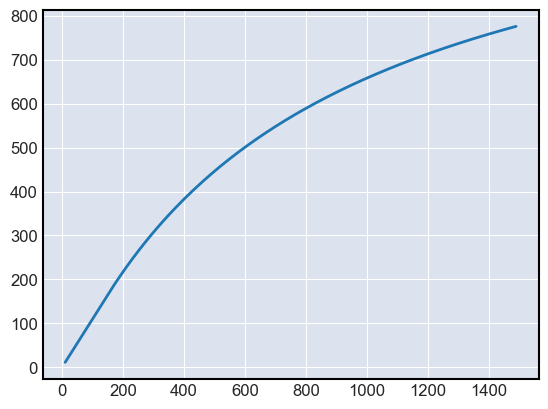

In [9]:
# for i in [100,500,800,2000,2100,5000, 5500, 6000, 68000,68300,69000,70000,100000,100300,101000,120000,120400,121000,121100]:
#     print(i,end=' ')
#     print(math.log(1+math.exp(i/10000)))

import math

def normalize_k_smart(k, threshold=150, power=0.8):
    """
    Сохраняет почти линейный рост, но замедляет большие значения
    power=0.8 - почти линейно, но немного замедляет
    """
    if k <= threshold:
        return k
    else:
        diff = k - threshold
        # Линейная часть + замедленная часть
        return threshold + diff * (diff ** (power - 1))

# Или лучше так:
def normalize_k_better(k, threshold=150, slowdown=0.1):
    if k<=threshold:
        return k*1.1
    else:
        diff=k-threshold
        growth=diff/(1+slowdown*diff/95)
        return (threshold+growth)*1.1
    
x=[]
y=[]
for i in range(10,1500,10):
    x.append(i)
    y.append(normalize_k_better(i))
    # my volue: math.log(1+math.exp(i/10000))
    #y.append(i*0.0001)
    #y.append((math.pow(math.pow(i,0.8,),1/5)-3)*math.pow(i,0.2)/2)

    #y.append(((math.pow(i,0.16) - 3) * math.pow(i,0.4)) / math.log(i))
'''
x=np.array(range(10000,12000,100))
y=((x/x[0])-1)*10'''
plt.plot(x,y)
plt.show()

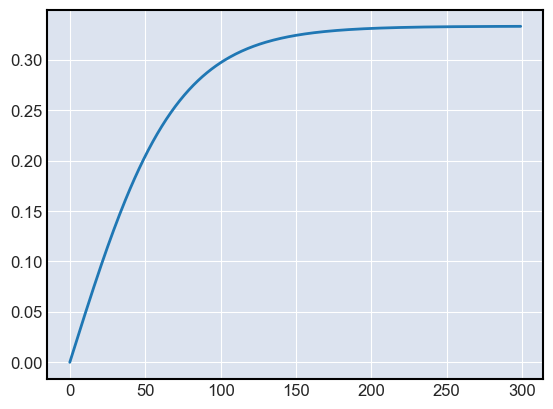

In [10]:
# for i in [100,500,800,2000,2100,5000, 5500, 6000, 68000,68300,69000,70000,100000,100300,101000,120000,120400,121000,121100]:
#     print(i,end=' ')
#     print(math.log(1+math.exp(i/10000)))

import math

# Или лучше так:
def normalize_k_better(k, threshold=150, slowdown=0.1):
    return np.tanh(k/70)/3
def f(e):
    return np.clip(e*0.8,-1,5)
x=[]
y=[]
for i in range(0,300,1):
    x.append(i)
    y.append(normalize_k_better(i))
    # my volue: math.log(1+math.exp(i/10000))
    #y.append(i*0.0001)
    #y.append((math.pow(math.pow(i,0.8,),1/5)-3)*math.pow(i,0.2)/2)

    #y.append(((math.pow(i,0.16) - 3) * math.pow(i,0.4)) / math.log(i))
'''
x=np.array(range(10000,12000,100))
y=((x/x[0])-1)*10'''
plt.plot(x,y)
plt.show()

In [11]:
path1=Path("D:\\Python1\\AI\\cripto_bot\\from_2.parquet")  # 15m
path2=Path("D:\\Python1\\AI\\cripto_bot\\from_2_2.parquet") # 4h
path3=Path("D:\\Python1\\AI\\cripto_bot\\from_1_2.parquet") # 1w

f0=pd.read_parquet(path1)
f1=pd.read_parquet(path2)
f2=pd.read_parquet(path3)

#'timestamp', 'open', 'high', 'low', 'close', 'volue', 'rsi', 'adx',       'bb', 'obv', 'atr'
def prin(f):
    
    start=f['timestamp'].iloc[0]
    print('start:',start)
    #for i in range(1,len(f)):
     #   if start+ datetime.timedelta(7)!= f['timestamp'].iloc[i]:
      #      print('eror:',i)
       # start=f['timestamp'].iloc[i]
    return f['timestamp'].iloc[0] 
start1 =prin(f0)
start2 =prin(f1)
start3 =prin(f2)
print(f'15m start: {start1}')
print(f'delta 15m per 4h: {(start1 -start2)}')
print(f'delta 15m per 1w: {(start1-start3)/datetime.timedelta(minutes=240)}')
print(f'delta 4h per 1w: {(start2-start3)/datetime.timedelta(minutes=240)}')
start2=f1['timestamp'].iloc[100]
index2=100
print('-----------------------------------')
for i in range(len(f0['timestamp'])):
    if start2+datetime.timedelta(hours=3,minutes=44)<=f0['timestamp'].iloc[i]:
        index1=i
        print(f"next 4h: {f1['timestamp'].iloc[101]}")
        start1=f0['timestamp'].iloc[i]
        print(f'index1:',index1)
        print(f'open 15m:',start1)
        print('--------------------------------------------')
        break



print('-----------------------------------')
for i in range(len(f2['timestamp'])):
    if start2<=f2['timestamp'].iloc[i]:
        index3=i-2
        print(f"next 4h: {f1['timestamp'].iloc[101]}")
        start3=f2['timestamp'].iloc[i-2]
        print(f'index2:',index3)
        print(f'open 1w:',start3)
        print('--------------------------------------------')
        break







start: 2019-04-01 05:30:00+00:00
start: 2018-01-05 16:00:00+00:00
start: 2018-07-16 00:00:00+00:00
15m start: 2019-04-01 05:30:00+00:00
delta 15m per 4h: 450 days 13:30:00
delta 15m per 1w: 1555.375
delta 4h per 1w: -1148.0
-----------------------------------
next 4h: 2018-01-22 12:00:00+00:00
index1: 0
open 15m: 2019-04-01 05:30:00+00:00
--------------------------------------------
-----------------------------------
next 4h: 2018-01-22 12:00:00+00:00
index2: -2
open 1w: 2025-12-08 00:00:00+00:00
--------------------------------------------


In [12]:
import birja_copy as bc
import numpy as np
import pandas as pd
import mplfinance as mpl
np.set_printoptions(threshold=np.inf)
a=bc.Trading_3()
a.index1+=2
t=a._get_observation()

time=np.array(range(100))
b=pd.DataFrame(t['window_data']['4h'][:,:5],columns=['Open','High','Low','Close','Volume'])
b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')
c=pd.DataFrame(t['window_data']['4h'],columns=['Open','High','Low','Close','Volume','rsi','adx','bb','atr'])


c1=pd.DataFrame(np.reshape(t['global'],(1,4)),columns=['15m','4h','1w','now'])

#with open('analiz.txt' ,'w') as f:
 #   f.write(str(a._get_observation()))
mpl.plot(b, type="candle", volume=True)
mpl.plot()
#c[:40]
c[-30:]

start2: 2018-12-13 00:00:00+00:00 | index2: 2048 | start2(for index): 2018-12-13 00:00:00+00:00 end: 2025-12-24 00:00:00+00:00
start1: 2018-12-13 04:00:00+00:00 | index1: 277 | start1(for index): 2018-12-13 04:00:00+00:00 end: 2025-12-24 07:30:00+00:00
start3: 2018-12-03 00:00:00+00:00 | index3: 20 | start3(for index): 2018-12-03 00:00:00+00:00 end: 2025-12-15 00:00:00+00:00


TypeError: tuple indices must be integers or slices, not str

In [ ]:
import birja_copy as bc
import numpy as np
import pandas as pd
import mplfinance as mpl
import random
import builtins
import json
from pathlib import Path 
a=bc.Trading_3()
o=0
s=True
for i in range(100000):
    a.index1+=1

    a.trader()
    c=a._get_observation()
    if i%20==0 and s:
        c2=c
        s=False
        c3=a.get_index(c)
    #print(c['window_data']['15m'][:,3])
    
    b=pd.DataFrame(c['window_data']['15m'][-60:,:5],columns=['Open','High','Low','Close','Volume'])
    b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')
    c1=pd.DataFrame(np.reshape(c['global'],(1,4)),columns=['15m','4h','1w','now'])

    #with open('analiz.txt' ,'w') as f:
    #   f.write(str(a._get_observation()))
    
    #action=random.randint(0,2)
    if i%20==0:
        if i>=60:
            print(f"До:, a.index2:{a.index2}, a.index3:{a.index3}, a.start2:{a.start2}, a.start3:{a.start3}, stop:{a.stop}, take:{a.take}, open:{a.open}, un:{a.unrealized_pnl}, time_in_tdare:{a.time_in_trade}, dir:{a.direction}, prise:{a.prise}")
            c2=a.get_obsevation_for_index(c3)

            print(f"после:, a.index2:{a.index2}, a.index3:{a.index3}, a.start2:{a.start2}, a.start3:{a.start3}, stop:{a.stop}, take:{a.take}, open:{a.open}, un:{a.unrealized_pnl}, time_in_tdare:{a.time_in_trade}, dir:{a.direction}, prise:{a.prise}")

            with builtins.open(Path(f'D:\Python1\AI\cripto_bot\debag\data_to_{i}.json'),'w') as f:
                c1={'window_data':{
                    '15m': c2['window_data']['15m'].tolist(),
                    '4h': c2['window_data']['4h'].tolist(),
                    '1w': c2['window_data']['1w'].tolist(),
                },
                'action_one_hot': c2['action_one_hot'].tolist(),
                'scalars': c2['scalars'].tolist(),
                "global":c2["global"].tolist(),
                'level':c2['level'].tolist(),
                'un_pnl':c2['un_pnl'].tolist(),
                'time_in_trade':c2['time_in_trade'].tolist(),
                'time':datetime.datetime.isoformat(a.data_15['timestamp'].iloc[a.index1])}
                json.dump(c1,f,indent=3)
        with builtins.open(Path(f'D:\Python1\AI\cripto_bot\debag\data_{i}.json'),'w') as f:
            c1={'window_data':{
                '15m': c['window_data']['15m'].tolist(),
                '4h': c['window_data']['4h'].tolist(),
                '1w': c['window_data']['1w'].tolist(),
            },
            'action_one_hot': c['action_one_hot'].tolist(),
            'scalars': c['scalars'].tolist(),
            "global":c["global"].tolist(),
            'level':c['level'].tolist(),
            'un_pnl':c['un_pnl'].tolist(),
            'time_in_trade':c['time_in_trade'].tolist(),
            'time':datetime.datetime.isoformat(a.data_15['timestamp'].iloc[a.index1])}
            json.dump(c1,f,indent=3)
        mpl.plot(b, type="candle", volume=True,hlines=dict(hlines=c['level'].tolist(),colors=['blue','green','red'],linewidths=1, linestyle='--'),figsize=(18,10))
        

        
        action,open,stop,take=[float(input(f'input {i}:')) for i in ['sc','o','s','t']]
    else:
        action,open,stop,take=[0,0,0,0]
   # print('ac:',action,'| o:',open,'| s:',stop,'| t:',take)

    #take,open=np.random.normal(0,0.2,2)
    #print('action:',action,'stop:',stop,'take:',take,'open:',open)
    a._trade(action,stop,take,open)
    print(f'step:{i:4d}',f'| balanse:{a.balance:.4f}')
    #print('-'*40)




start2: 2018-12-13 00:00:00+00:00 | index2: 2048 | start2(for index): 2018-12-13 00:00:00+00:00 end: 2025-12-24 00:00:00+00:00
start1: 2018-12-13 04:00:00+00:00 | index1: 277 | start1(for index): 2018-12-13 04:00:00+00:00 end: 2025-12-24 07:30:00+00:00
start3: 2018-12-03 00:00:00+00:00 | index3: 20 | start3(for index): 2018-12-03 00:00:00+00:00 end: 2025-12-15 00:00:00+00:00


C:\Users\Comp\AppData\Local\Temp\ipykernel_5232\1295619280.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')


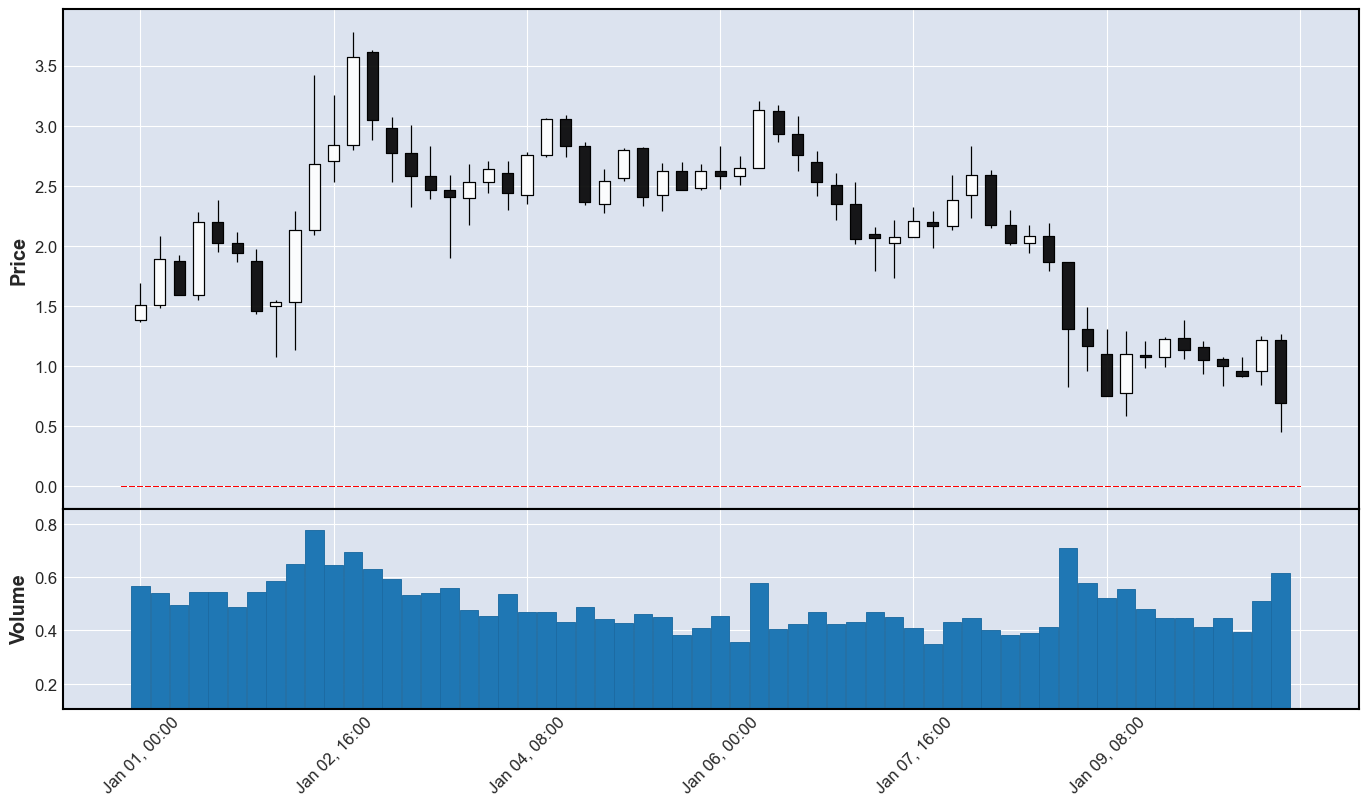

reward _trade: 0.5
reward trade: 0.4
step:   0 | balanse:100.0000| reward:-0.10000| a.index1:278 |a.index2:2048, a.index3:20, a.start2:2018-12-13 00:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 04:15:00+00:00| reward:-0.100| done:False| tr:False | take:0.0626| stop:-0.0069| open:0.0200| prise:3388.24| dir:1| unp:0.0000
action: 1.0| open: 2.0| stop: 0.0| take: 7.0| op_k:False| unp:0.000| pries:3388.24
reward _trade: 0.0
reward trade: -0.1
step:   1 | balanse:100.0000| reward:-0.60000| a.index1:279 |a.index2:2048, a.index3:20, a.start2:2018-12-13 00:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 04:30:00+00:00| reward:-0.600| done:False| tr:False | take:0.0626| stop:-0.0069| open:0.0200| prise:3388.24| dir:1| unp:0.0000
action: 0| open: 0| stop: 0| take: 0| op_k:False| unp:0.000| pries:3388.24
reward _trade: 0.0
reward trade: -0.1
step:   2 | balanse:100.0000| reward:-0.60000| a.index1:280 |a.index2:2048, a.index3:20, a.start2:2018-12-13 00:0

C:\Users\Comp\AppData\Local\Temp\ipykernel_5232\1295619280.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')


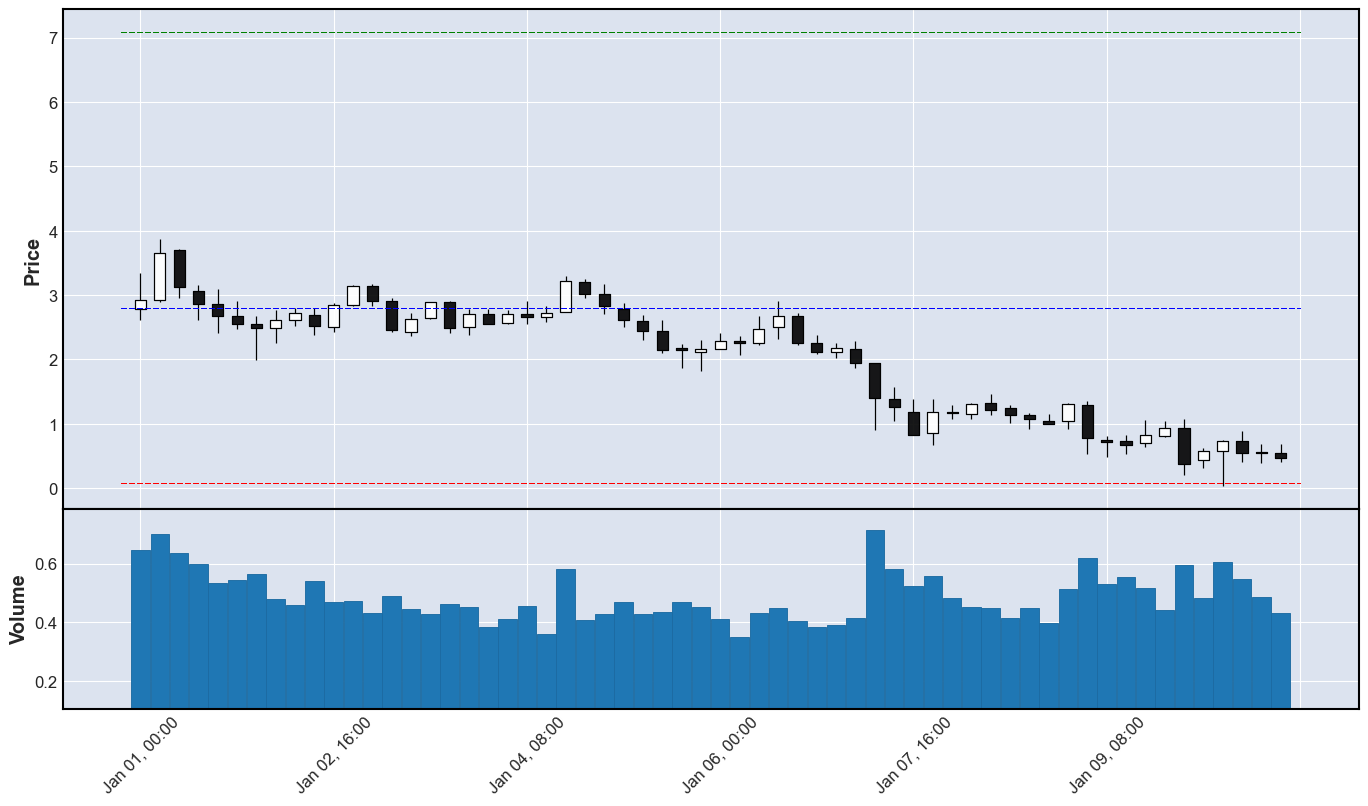

reward _trade: 0.0
reward trade: -0.1
step:  10 | balanse:100.0000| reward:-0.60000| a.index1:288 |a.index2:2048, a.index3:20, a.start2:2018-12-13 00:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 06:45:00+00:00| reward:-0.600| done:False| tr:False | take:0.0626| stop:-0.0069| open:0.0200| prise:3388.24| dir:1| unp:0.0000
action: 1.0| open: 0.0| stop: 0.0| take: 3.0| op_k:False| unp:0.000| pries:3388.24
reward _trade: 0.0
reward trade: -0.1
step:  11 | balanse:100.0000| reward:-0.60000| a.index1:289 |a.index2:2048, a.index3:20, a.start2:2018-12-13 00:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 07:00:00+00:00| reward:-0.600| done:False| tr:False | take:0.0626| stop:-0.0069| open:0.0200| prise:3388.24| dir:1| unp:0.0000
action: 0| open: 0| stop: 0| take: 0| op_k:False| unp:0.000| pries:3388.24
reward _trade: 0.0
reward trade: -0.1
step:  12 | balanse:100.0000| reward:-0.60000| a.index1:290 |a.index2:2048, a.index3:20, a.start2:2018-12-13 00:

C:\Users\Comp\AppData\Local\Temp\ipykernel_5232\1295619280.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')


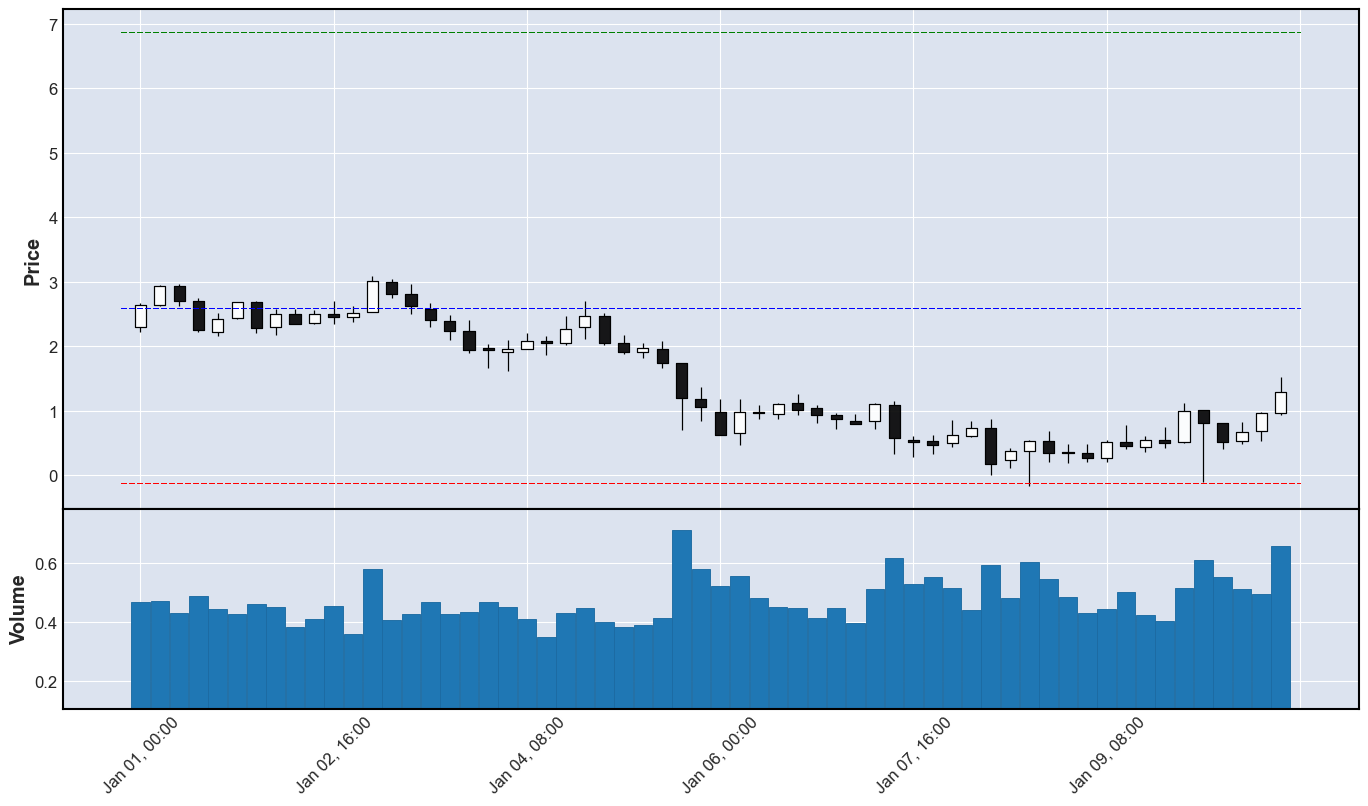

reward _trade: -0.5
reward trade: -0.5
step:  20 | balanse:100.0000| reward:-1.00000| a.index1:298 |a.index2:2049, a.index3:20, a.start2:2018-12-13 04:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 09:15:00+00:00| reward:-1.000| done:False| tr:False | take:0.0000| stop:0.0000| open:0.0000| prise:0.00| dir:0| unp:0.0000
action: 2.0| open: 1.0| stop: 2.0| take: 1.0| op_k:False| unp:0.000| pries:0
reward _trade: -0.25
reward trade: -0.25
step:  21 | balanse:100.0000| reward:-0.75000| a.index1:299 |a.index2:2049, a.index3:20, a.start2:2018-12-13 04:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 09:30:00+00:00| reward:-0.750| done:False| tr:False | take:0.0000| stop:0.0000| open:0.0000| prise:0.00| dir:0| unp:0.0000
action: 0| open: 0| stop: 0| take: 0| op_k:False| unp:0.000| pries:0
reward _trade: -0.25
reward trade: -0.25
step:  22 | balanse:100.0000| reward:-0.75000| a.index1:300 |a.index2:2049, a.index3:20, a.start2:2018-12-13 04:00:00+00:00, 

C:\Users\Comp\AppData\Local\Temp\ipykernel_5232\1295619280.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')


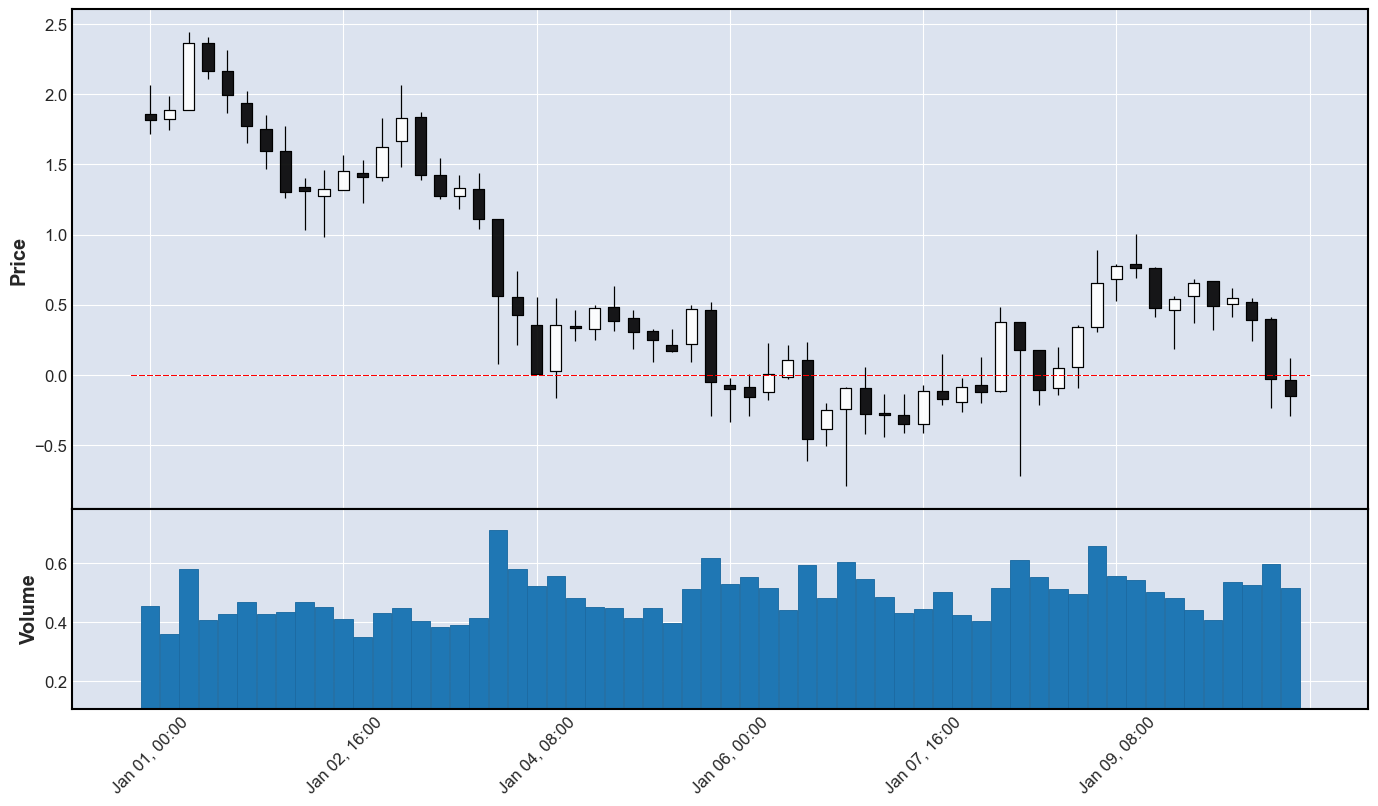

reward _trade: 0.5
reward trade: 1.5
step:  30 | balanse:100.0000| reward:1.00000| a.index1:308 |a.index2:2049, a.index3:20, a.start2:2018-12-13 04:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 11:45:00+00:00| reward:1.000| done:False| tr:False | take:0.0215| stop:-0.0185| open:0.0000| prise:3384.88| dir:1| unp:0.0000
action: 1.0| open: 0.0| stop: -2.0| take: 2.0| op_k:True| unp:0.000| pries:3384.88
reward _trade: 0.0
reward trade: 0.04396893601220836
step:  31 | balanse:100.0000| reward:-0.45603| a.index1:309 |a.index2:2050, a.index3:20, a.start2:2018-12-13 08:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 12:00:00+00:00| reward:-0.456| done:False| tr:False | take:0.0215| stop:-0.0185| open:0.0000| prise:3384.88| dir:1| unp:0.0468
action: 0| open: 0| stop: 0| take: 0| op_k:True| unp:0.047| pries:3384.88
reward _trade: 0.0
reward trade: 0.5869227535479253
step:  32 | balanse:100.0000| reward:0.08692| a.index1:310 |a.index2:2050, a.index3:20,

C:\Users\Comp\AppData\Local\Temp\ipykernel_5232\1295619280.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')


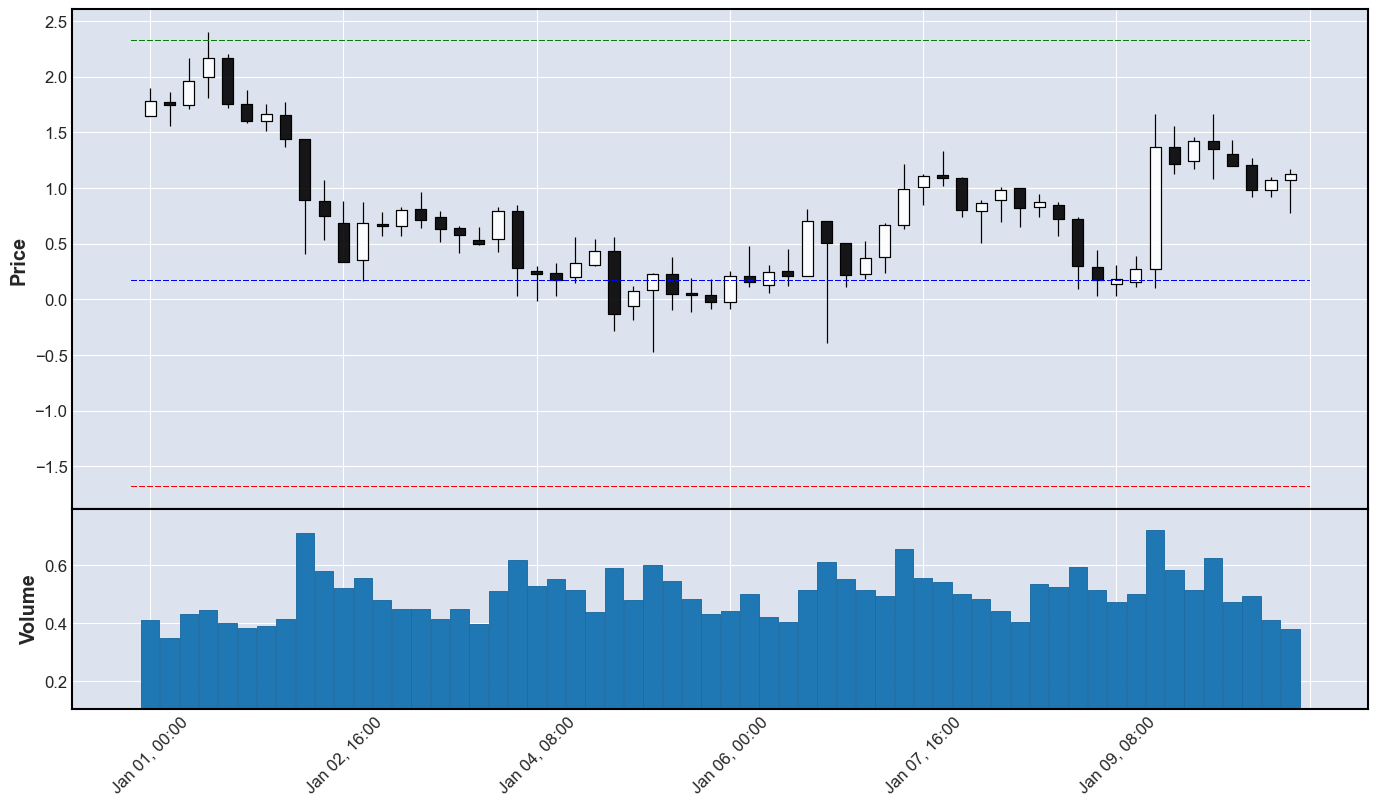

reward _trade: 3.8139080926548963
reward trade: 3.8139080926548963
step:  40 | balanse:100.5101| reward:3.81646| a.index1:318 |a.index2:2050, a.index3:20, a.start2:2018-12-13 08:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 14:15:00+00:00| reward:3.816| done:False| tr:False | take:0.0000| stop:0.0000| open:0.0000| prise:0.00| dir:0| unp:0.0000
action: 2.0| open: 3.0| stop: 4.0| take: 5.0| op_k:False| unp:0.000| pries:0
reward _trade: -0.25
reward trade: -0.25
step:  41 | balanse:100.5101| reward:-0.24745| a.index1:319 |a.index2:2050, a.index3:20, a.start2:2018-12-13 08:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, a.start1:2018-12-13 14:30:00+00:00| reward:-0.247| done:False| tr:False | take:0.0000| stop:0.0000| open:0.0000| prise:0.00| dir:0| unp:0.0000
action: 0| open: 0| stop: 0| take: 0| op_k:False| unp:0.000| pries:0
reward _trade: -0.25
reward trade: -0.25
step:  42 | balanse:100.5101| reward:-0.24745| a.index1:320 |a.index2:2050, a.index3:20, a.start2:2

C:\Users\Comp\AppData\Local\Temp\ipykernel_5232\1295619280.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')


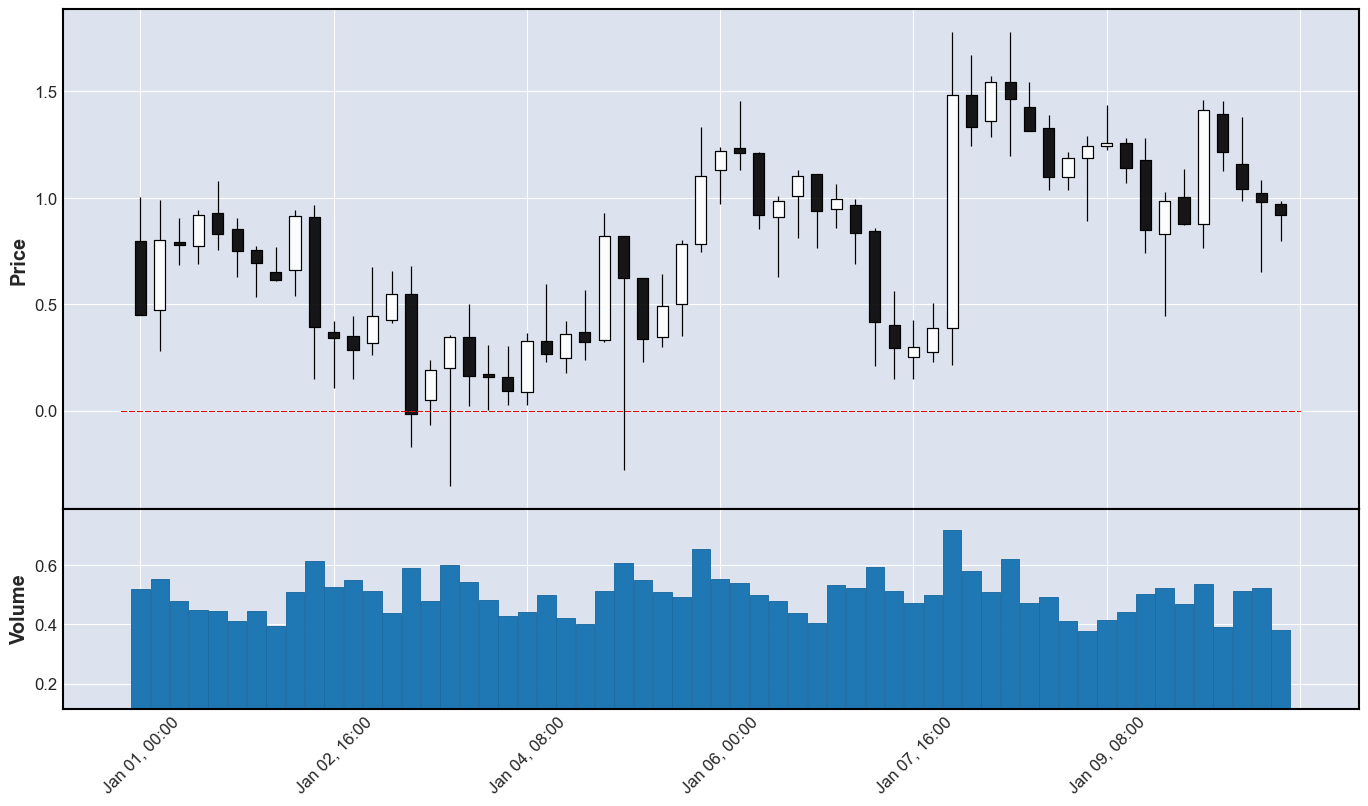

ValueError: could not convert string to float: ''

In [1]:
import birja_copy as bc
import numpy as np
import pandas as pd
import mplfinance as mpl
import random
import builtins
import json
from pathlib import Path 
a=bc.Trading_3()
o=0
s=True
done=False
c,o=a.reset()

for i in range(0,10000000,1):
    if done:
        break
    
    #print(c['window_data']['15m'][:,3])
    
    #c1=pd.DataFrame(np.reshape(c['global'],(1,4)),columns=['15m','4h','1w','now'])

    #with open('analiz.txt' ,'w') as f:
    #   f.write(str(a._get_observation()))
    
    #action=random.randint(0,2)
    if i%10==0 :
        
            # print(f"после:, a.index2:{a.index2}, a.index3:{a.index3}, a.start2:{a.start2}, a.start3:{a.start3}, stop:{a.stop}, take:{a.take}, open:{a.open}, un:{a.unrealized_pnl}, time_in_tdare:{a.time_in_trade}, dir:{a.direction}, prise:{a.prise}")
        b=pd.DataFrame(c['window_data']['15m'][-60:,:5],columns=['Open','High','Low','Close','Volume'])
        b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')
    
        mpl.plot(b, type="candle", volume=True,hlines=dict(hlines=c['level'].tolist(),colors=['blue','green','red'],linewidths=1, linestyle='--'),figsize=(18,10))
        

        
        action,open,stop,take=[float(input(f'input {i}:')) for i in ['sc','o','s','t']]
    else:
        action,open,stop,take=[0,0,0,0]
    c,reward,done,tr,info=a.step(action,take,stop,open)
    if tr:
        print('aaaaaaaaaa')
        print('balanse:',balanse)
    balanse=a.balance

    print(f'step:{i:4d}',f'| balanse:{a.balance:.4f}| reward:{reward:.5f}| a.index1:{a.index1} |a.index2:{a.index2}, a.index3:{a.index3}, a.start2:{a.start2}, a.start3:{a.start3}, a.start1:{a.start1}| reward:{reward:.3f}| done:{done}| tr:{tr} | take:{a.take:.4f}| stop:{a.stop:.4f}| open:{a.open:.4f}| prise:{a.prise:.2f}| dir:{a.direction}| unp:{a.unrealized_pnl:.4f}')
    print(f'action: {action}| open: {open}| stop: {stop}| take: {take}| op_k:{a.open_k}| unp:{a.unrealized_pnl:.3f}| pries:{a.prise}')




In [2]:
#  загрузка полной модели
import Memory
from keras import layers as lay
import keras
import PPO_model2
num_action=env.action_space
# {'scalars':3,'level':3} # 3 действия 3 уровня
gamma=0.99
lam=0.95
# ,custom_objects={'Memory':Memory.Memory,'ReadMemory':Memory.ReadMemory,"WriteMemory":Memory.WriteMemory}
actor=keras.saving.load_model(r"D:\Python1\AI\cripto_bot\models\actor_last_005 (5).keras")

ValueError: A total of 3 objects could not be loaded. Example error message for object <Memory name=memory_15, built=True>:

Layer 'memory_15' expected 5 variables, but received 0 variables during loading. Expected: ['variable_15', 'variable_16', 'variable_17', 'variable_18', 'variable_19']

List of objects that could not be loaded:
[<Memory name=memory_15, built=True>, <Memory name=memory_4, built=True>, <Memory name=memory_1, built=True>]

------------------------------TEST----------------------------------

In [1]:
import tensorflow as tf
import numpy as np
import datetime
#import birja_copy as bc
import birja1 as bc
import numpy as np
import pandas as pd
import mplfinance as mpl
import random
import builtins
import json
from pathlib import Path 
env=bc.Trading_3()
o=0
s=True
done=False


def step(action=0,cout=(0,0,0)):

    '''возвращение парамертров  step  в тензорах'''
    cout=tf.squeeze(cout).numpy().tolist()
    action=action.numpy().tolist()
    observation,reward__,done,trun,info=env.step(action=int(action),stop=float(cout[0]),take=float(cout[1]),open=float(cout[2]))
    #{'window_data':datas,"action_one_hot":dirat,"scalars":scalar,"global":global_level,'level':level,'un_pnl':un_pnl,'time_in_trade':time_in_t}
    #'15m':None,'4h':None,'1w':None
    with tf.device('/GPU:0'):
      observation_window={'15m':tf.reshape(tf.constant(observation['window_data']['15m'],tf.float32),(1,env.window_15,9)),
                          '4h':tf.reshape(tf.constant(observation['window_data']['4h'],tf.float32),(1,env.window_4+1,9)),
                          '1w':tf.reshape(tf.constant(observation['window_data']['1w'],tf.float32),(1,env.window_1+1,9))}

      observation={**observation_window,
                  'action_one_hot':tf.reshape(tf.constant(observation['action_one_hot'],tf.float32),(1,4,)),
                  'scalars':tf.reshape(tf.constant(observation['scalars'],tf.float32),(1,4,)),
                  'global':tf.reshape(tf.constant(observation['global'],tf.float32),(1,4,)),
                  'level':tf.reshape(tf.constant(observation['level'],tf.float32),(1,3,)),
                  'un_pnl':tf.reshape(tf.constant(observation['un_pnl'],tf.float32),(1,1,)),
                  'time_in_trade':tf.reshape(tf.constant(observation['time_in_trade'],tf.float32),(1,1,))
                  }
      reward__=tf.tanh(tf.constant(reward__,tf.float32))
      done=done or trun
      done=tf.constant(float(done),tf.float32)
      trun=tf.constant(bool(done),tf.bool)
      #return observation[0],observation[1],observation[2],reward__,done,trun
      info1={}
      info1['1w']=tf.reshape(tf.constant(info['1w'],tf.bool),(1,1))
      info1['4h']=tf.reshape(tf.constant(info['4h'],tf.bool),(1,1))

    return observation,reward__,done,trun,info1

#@tf.py_function(Tout=[tf.float32,tf.float32,tf.float32])
def reset(e=True):
    if e:
        obs,info=env.reset()
    else:
        with open(Path(r"D:\Python1\AI\cripto_bot\models\last_obs_301.json"),'r') as f:
            dat=json.load(f)
        obs,info=env.get_obsevation_for_index(dat)  
        
    with tf.device('/GPU:0'):
      observation_window={'15m':tf.reshape(tf.constant(obs['window_data']['15m'],tf.float32),(1,env.window_15,9)),
                          '4h':tf.reshape(tf.constant(obs['window_data']['4h'],tf.float32),(1,env.window_4+1,9)),
                          '1w':tf.reshape(tf.constant(obs['window_data']['1w'],tf.float32),(1,env.window_1+1,9))}

      obs={**observation_window,
                  'action_one_hot':tf.reshape(tf.constant(obs['action_one_hot'],tf.float32),(1,4,)),
                  'scalars':tf.reshape(tf.constant(obs['scalars'],tf.float32),(1,4,)),
                  'global':tf.reshape(tf.constant(obs['global'],tf.float32),(1,4,)),
                  'level':tf.reshape(tf.constant(obs['level'],tf.float32),(1,3,)),
                  'un_pnl':tf.reshape(tf.constant(obs['un_pnl'],tf.float32),(1,1,)),
                  'time_in_trade':tf.reshape(tf.constant(obs['time_in_trade'],tf.float32),(1,1,))
                  }
      #return obs[0],obs[1],obs[2]
      tf.print(obs.keys())
      info1={}
      info1['1w']=tf.reshape(tf.constant(info['1w'],tf.bool),(1,1))
      info1['4h']=tf.reshape(tf.constant(info['4h'],tf.bool),(1,1))
    return obs,info1


@tf.function(jit_compile=True)
def get_discounted_sum(x,gamma):
    x=tf.cast(x[::-1],tf.float32)
    gamma=tf.constant(gamma,tf.float32)
    y=tf.TensorArray(tf.float32,0,dynamic_size=True)
    y0=tf.constant(0.0)
    y0_shape=y0.shape
    for i in tf.range(tf.shape(x)[0]):
        y0=x[i]+y0*gamma
        y0=tf.reshape(y0,y0_shape)
        y=y.write(i,y0)

    return y.stack()[::-1]




start2: 2018-12-13 00:00:00+00:00 | index2: 2048 | start2(for index): 2018-12-13 00:00:00+00:00 end: 2025-12-24 00:00:00+00:00
start1: 2018-12-13 04:00:00+00:00 | index1: 277 | start1(for index): 2018-12-13 04:00:00+00:00 end: 2025-12-24 07:30:00+00:00
start3: 2018-12-03 00:00:00+00:00 | index3: 20 | start3(for index): 2018-12-03 00:00:00+00:00 end: 2025-12-15 00:00:00+00:00


In [2]:
from pathlib import Path
import json
with open(Path(r"D:\Python1\AI\cripto_bot\models\actor_last_005 (5)\metadata.json"),'r') as f:
    data=json.load(f)
with open(Path(r"D:\Python1\AI\cripto_bot\models\actor_last_005 (5)\metadata_1.json"),'w') as f:
    json.dump(data,f,indent=3) 

In [ ]:
import h5py
h5py

In [2]:
# загрузка из весов
import Memory
from keras import layers as lay
import keras
import PPO_model2
num_action=env.action_space
# {'scalars':3,'level':3} # 3 действия 3 уровня
gamma=0.99
lam=0.95


observations_data,info=reset(False)

mem_15m = Memory.Memory(128,48,48, name_='15', name='memory_15')
mem_4h  = Memory.Memory(128,64,64, name_='4', name='memory_4')
mem_1w  = Memory.Memory(64,128,128, name_='1', name='memory_1')

tf1=lay.Input((env.window_15,9),name='15m')
tf2=lay.Input((env.window_4+1,9),name='4h')
tf3=lay.Input((env.window_1+1,9),name='1w')
act_hot=lay.Input((4,),name='action_one_hot')
sclr=lay.Input((4,),name='scalars')
glob=lay.Input((4,),name='global')
lvl=lay.Input((3,),name='level')
un_pnl=lay.Input((1,),name='un_pnl')
t_in_tr=lay.Input((1,),name='time_in_trade')
can_w15=lay.Input((1,),dtype=tf.bool,name='can_write15')
can_w4=lay.Input((1,),dtype=tf.bool,name='can_write4')
can_w1=lay.Input((1,),dtype=tf.bool,name='can_write1')
can_r15=lay.Input((1,),dtype=tf.bool,name='can_read15')
can_r4=lay.Input((1,),dtype=tf.bool,name='can_read4')
can_r1=lay.Input((1,),dtype=tf.bool,name='can_read1')
vector_h15=lay.Input((48,),dtype=tf.float32,name='vector_r15')
vector_h4=lay.Input((64,),dtype=tf.float32,name='vector_r4')
vector_h1=lay.Input((128,),dtype=tf.float32,name='vector_r1')


conv_1=lay.Conv1D(32,5,activation='gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(tf1)
conv_2=lay.Conv1D(64,7,activation='gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(tf2)
conv_3=lay.Conv1D(128,5,activation='gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(tf3)

conv_1=lay.Conv1D(48,3,activation='gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(conv_1)
conv_2=lay.Conv1D(64,5,activation='gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(conv_2)
#conv_3=lay.Conv1D(128,3,activation='gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(conv_3)

transform1=PPO_model2.Transformer_block(num_head=4,key_dim=12,d_ff=96,num=1,value_dim=16,l=6,num_experts=8,top_k=2)(conv_1)
transform2=PPO_model2.Transformer_block(num_head=4,key_dim=16,d_ff=128,num=1,value_dim=16,l=4,num_experts=8,top_k=2)(conv_2)
transform3=PPO_model2.Transformer_block(num_head=8,key_dim=16,d_ff=256,num=1,value_dim=16,l=2,num_experts=8,top_k=2)(conv_3)

transform1=PPO_model2.Transformer_block(num_head=4,key_dim=12,d_ff=96,num=2,value_dim=16,l=6,num_experts=8,top_k=2)(transform1)
transform2=PPO_model2.Transformer_block(num_head=4,key_dim=16,d_ff=128,num=2,value_dim=16,l=4,num_experts=8,top_k=2)(transform2)
transform3=PPO_model2.Transformer_block(num_head=8,key_dim=16,d_ff=256,num=2,value_dim=16,l=2,num_experts=8,top_k=2)(transform3)

transform1=PPO_model2.Transformer_block(num_head=4,key_dim=12,d_ff=96,num=3,value_dim=16,l=6,num_experts=8,top_k=2)(transform1)
transform2=PPO_model2.Transformer_block(num_head=4,key_dim=16,d_ff=128,num=3,value_dim=16,l=4,num_experts=8,top_k=2)(transform2)

transform1=PPO_model2.Transformer_block(num_head=4,key_dim=12,d_ff=96,num=4,value_dim=16,l=6,num_experts=8,top_k=2)(transform1)
transform2=PPO_model2.Transformer_block(num_head=4,key_dim=16,d_ff=128,num=4,value_dim=16,l=4,num_experts=8,top_k=2)(transform2)

transform1=PPO_model2.Transformer_block(num_head=4,key_dim=12,d_ff=96,num=5,value_dim=16,l=6,num_experts=8,top_k=2)(transform1)

transform1=PPO_model2.Transformer_block(num_head=4,key_dim=12,d_ff=96,num=6,value_dim=16,l=6,num_experts=8,top_k=2)(transform1)

gl_max1=lay.GlobalAveragePooling1D()(transform1)
gl_max2=lay.GlobalAveragePooling1D()(transform2)
gl_max3=lay.GlobalAveragePooling1D()(transform3)


read1=Memory.ReadMemory(mem_15m,48,8)(gl_max1,can_r=can_r15,vector_h=vector_h15)
read2=Memory.ReadMemory(mem_4h,64,16)(gl_max2,can_r=can_r4,vector_h=vector_h4)
read3=Memory.ReadMemory(mem_1w,128,16)(gl_max3,can_r=can_r1,vector_h=vector_h1)

k_new1,v_new1,p1=Memory.WriteMemory(mem_15m,tf_name='15m',o_f=0.4,n_f=0.05,a_f=1,s_max=0.65)(gl_max1,can_write=can_w15)
k_new2,v_new2,p2=Memory.WriteMemory(mem_4h,tf_name='4h',o_f=0.6,n_f=0.03,a_f=1,s_max=0.65)(gl_max2,can_write=can_w4)
k_new3,v_new3,p3=Memory.WriteMemory(mem_1w,tf_name='1w',o_f=0.7,n_f=0.02,a_f=1,s_max=0.65)(gl_max3,can_write=can_w1)


read=lay.Concatenate()([read1,read2,read3])
context=lay.Concatenate()([gl_max1,gl_max2,gl_max3])

context=lay.Dense(128,'gelu',kernel_regularizer=keras.regularizers.l2(1e-3))(context)
read=lay.Dense(128,'gelu',kernel_regularizer=keras.regularizers.l2(1e-3))(read)
context=lay.LayerNormalization()(context)
read=lay.LayerNormalization()(read)


sclr1=lay.Dense(16,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(sclr)
act_hot1=lay.Dense(16,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(act_hot)
glob1=lay.Dense(16,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(glob)
lvl1=lay.Dense(16,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(lvl)
un_pnl1=lay.Dense(8,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(un_pnl)
t_in_tr1=lay.Dense(8,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(t_in_tr)


context=lay.Concatenate()([context,read,sclr1,act_hot1,glob1,lvl1,un_pnl1,t_in_tr1])
context1=lay.Dropout(0.1)(context)
context=lay.Dense(128,'gelu',kernel_regularizer=keras.regularizers.l2(1e-3))(context1)
context=lay.LayerNormalization()(context)
# можно добавить отдельные головы для level  и разные context  для них тоже ------------------------------------------------------------------------------------------------------------------------------------------------
# так же можно пороовать разные коофиценты которые будут влиять на то какой тф луцше
scal_act=lay.Dense(num_action['scalars'])(context)
mean_l=lay.Dense(2)(context)
std_l=lay.Dense(2)(context)
mean_l=20*keras.activations.tanh(mean_l/20)

mean_o=lay.Dense(1)(context)
mean_o=10*keras.activations.tanh(mean_o/10)
std_o=lay.Dense(1)(context)
predV=lay.Dense(1)(lay.concatenate([v_new1,v_new2,v_new3]))
actor=keras.Model(inputs={'15m':tf1,'4h':tf2,'1w':tf3,'action_one_hot':act_hot,'scalars':sclr,'global':glob,'level':lvl,'un_pnl':un_pnl,'time_in_trade':t_in_tr,'can_write15':can_w15,'can_write4':can_w4,'can_write1':can_w1,
                          'can_read15':can_r15,'can_read4':can_r4,'can_read1':can_r1,'vector_r15':vector_h15,'vector_r4':vector_h4,'vector_r1':vector_h1},
                  outputs={'scal_act':scal_act,'mean_l':mean_l,'mean_o':mean_o,
                           'std_l':std_l,'std_o':std_o,
                           'k1':k_new1,'v1':v_new1,'p1':p1,'gl_max1':gl_max1,'vector_r15':read1,
                           'k2':k_new2,'v2':v_new2,'p2':p2,'gl_max2':gl_max2,'vector_r4':read2,
                           'k3':k_new3,'v3':v_new3,'p3':p3,'gl_max3':gl_max3,'vector_r1':read3,'predv':predV})





transform1=PPO_model2.Transformer_block(num_head=4,key_dim=12,d_ff=96,num=1,value_dim=16,l=1,num_experts=4,top_k=2)(conv_1)
transform2=PPO_model2.Transformer_block(num_head=4,key_dim=16,d_ff=128,num=1,value_dim=16,l=1,num_experts=4,top_k=2)(conv_2)
transform3=PPO_model2.Transformer_block(num_head=8,key_dim=16,d_ff=256,num=1,value_dim=16,l=1,num_experts=4,top_k=2)(conv_3)

gl_max1=lay.GlobalAveragePooling1D()(transform1)
gl_max2=lay.GlobalAveragePooling1D()(transform2)
gl_max3=lay.GlobalAveragePooling1D()(transform3)

read1=Memory.ReadMemory(mem_15m,48,8)(gl_max1,can_r=can_r15,vector_h=vector_h15)
read2=Memory.ReadMemory(mem_4h,64,16)(gl_max2,can_r=can_r4,vector_h=vector_h4)
read3=Memory.ReadMemory(mem_1w,128,16)(gl_max3,can_r=can_r1,vector_h=vector_h1)


sclr1=lay.Dense(8,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(sclr)
act_hot1=lay.Dense(8,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(act_hot)
glob1=lay.Dense(8,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(glob)
lvl1=lay.Dense(8,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(lvl)
un_pnl1=lay.Dense(4,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(un_pnl)
t_in_tr1=lay.Dense(4,'gelu',kernel_regularizer=keras.regularizers.l2(1e-4))(t_in_tr)

context=lay.Concatenate()([gl_max1,gl_max2,gl_max3,read1,read2,read3,sclr1,act_hot1,glob1,lvl1,un_pnl1,t_in_tr1])

value=lay.Dense(1,kernel_regularizer=keras.regularizers.l2(1e-4))(context)
critic=keras.Model(inputs={'15m':tf1,'4h':tf2,'1w':tf3,'action_one_hot':act_hot,'scalars':sclr,'global':glob,'level':lvl,'un_pnl':un_pnl,'time_in_trade':t_in_tr,'can_write15':can_w15,'can_write4':can_w4,'can_write1':can_w1,'can_read15':can_r15,'can_read4':can_r4,'can_read1':can_r1,'vector_r15':vector_h15,'vector_r4':vector_h4,'vector_r1':vector_h1},
                   outputs=value)

critic.summary()

#keras.utils.plot_model(actor,'model_0.0.png',True,True,True)
#keras.utils.plot_model(critic,'model_0.1.png',True,True,True)



if True:
    keras.saving.load_weights(actor,Path(r"D:\Python1\AI\cripto_bot\models\actor_last_301.weights.h5"))
    #keras.saving.load_weights(critic,Path(r"D:\Python1\AI\cripto_bot\models\critic_last_006.weights.h5"))
    # for i in actor.weights:
    #     print(i)


['15m',
 '4h',
 '1w',
 'action_one_hot',
 'scalars',
 'global',
 'level',
 'un_pnl',
 'time_in_trade']



Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ 15m (InputLayer)    │ (None, 150, 9)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 4h (InputLayer)     │ (None, 100, 9)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 146, 32)   │      1,472 │ 15m[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 94, 64)    │      4,096 │ 4h[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 1w (InputLayer)     │ (None, 20, 9)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 144, 48)   │      4,656 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 90, 64)    │     20,544 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 16, 128)   │      5,888 │ 1w[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 144, 48)   │     70,580 │ conv1d_3[0][0]    │
│ (Transformer_block) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 90, 64)    │     92,152 │ conv1d_4[0][0]    │
│ (Transformer_block) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_… │ (None, 16, 128)   │    331,008 │ conv1d_2[0][0]    │
│ (Transformer_block) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 48)        │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ can_read15          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vector_r15          │ (None, 48)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ can_read4           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vector_r4           │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ can_read1           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 577,101 (2.31 MB)

 Trainable params: 501,981 (1.91 MB)

 Non-trainable params: 75,120 (407.08 KB)

In [ ]:
obs,info=reset(False)
print(f"До:, env.index2:{env.index2}, env.index3:{env.index3}, env.start2:{env.start2}, env.start3:{env.start3}, stop:{env.stop}, take:{env.take}, open:{env.open}, un:{env.unrealized_pnl}, time_in_tdare:{env.time_in_trade}, dir:{env.direction}, prise:{env.prise}")
balanse=env.balance
print(f"env.index2:{env.index2}, env.index3:{env.index3}, env.start2:{env.start2}, env.start3:{env.start3}, stop:{env.stop}, take:{env.take}, open:{env.open}, un:{env.unrealized_pnl}, time_in_tdare:{env.time_in_trade}, dir:{env.direction}, prise:{env.prise}")

for i in range(0,10000000,1):


    if i%1==0 :
        new_resolt = actor({
    '15m': obs['15m'],
    '4h': obs['4h'],
    '1w': obs['1w'],
    'level': obs['level'],
    'action_one_hot': obs['action_one_hot'],
    'un_pnl': obs['un_pnl'],
    'time_in_trade': obs['time_in_trade'],
    'global': obs['global'],
    'scalars': obs['scalars'],
    'can_write15': tf.constant([[True]], tf.bool),   # форма (1,1)
    'can_write4':  tf.constant([[True]], tf.bool),
    'can_write1':  tf.constant([[True]], tf.bool),
    'can_read15':  tf.constant([[True]],  tf.bool),
    'can_read4':   tf.constant([[True]],  tf.bool),
    'can_read1':   tf.constant([[True]],  tf.bool),
    'vector_r15': tf.zeros((1, 48), tf.float32),
    'vector_r4':  tf.zeros((1, 64), tf.float32),
    'vector_r1':  tf.zeros((1, 128), tf.float32)
}, training=False)
        logit=tf.cast(tf.reshape(new_resolt['scal_act'],(3,)),tf.float32)
        a_st=new_resolt['mean_l']
        a_o=new_resolt['mean_o']
        cout=tf.concat([a_st,a_o],-1)
        obs,reward,done,tru,info=step(tf.argmax(tf.squeeze(tf.nn.log_softmax(tf.expand_dims(logit,0)))),cout)
        print(f"env.index2:{env.index2}, env.index3:{env.index3}, env.start2:{env.start2}, env.start3:{env.start3}, stop:{env.stop}, take:{env.take}, open:{env.open}, un:{env.unrealized_pnl}, time_in_tdare:{env.time_in_trade}, dir:{env.direction}, prise:{env.prise}")
        #if i%60==0:
            #data_15m = obs['15m'].numpy().squeeze()  # теперь форма (window_15, 9)
            #b = pd.DataFrame(data_15m[-60:, :5], columns=['Open', 'High', 'Low', 'Close', 'Volume'])

            #b.index=pd.date_range('2024-01-01',periods=len(b),freq='4H')

            #mpl.plot(b, type="candle", volume=True,hlines=dict(hlines=tf.squeeze(cout).numpy().tolist(),colors=['blue','green','red'],linewidths=1, linestyle='--'),figsize=(18,10))
            

            


    balanse=env.balance
    if i%672==0:
        input()
    print(f'step:{i:4d}',f'| balanse:{env.balance:.4f}| reward:{reward:.5f}| env.index1:{env.index1} |env.index2:{env.index2}, env.index3:{env.index3}, env.start2:{env.start2}, env.start3:{env.start3}, env.start1:{env.start1}| reward:{reward:.3f}| done:{done} | take:{env.take:.4f}| stop:{env.stop:.4f}| open:{env.open:.4f}| prise:{env.prise:.2f}| dir:{env.direction}| unp:{env.unrealized_pnl:.4f}')
    print(f'cout: {cout} | action: {tf.argmax(tf.squeeze( tf.nn.log_softmax(tf.expand_dims(logit,0))))}| balanse:{env.balance}')
    #if i%60==0:
        #input()




['15m',
 '4h',
 '1w',
 'action_one_hot',
 'scalars',
 'global',
 'level',
 'un_pnl',
 'time_in_trade']
До:, env.index2:4274, env.index3:73, env.start2:2019-12-19 00:00:00+00:00, env.start3:2019-12-09 00:00:00+00:00, stop:0, take:0, open:0, un:0, time_in_tdare:0, dir:0, prise:0
env.index2:4274, env.index3:73, env.start2:2019-12-19 00:00:00+00:00, env.start3:2019-12-09 00:00:00+00:00, stop:0, take:0, open:0, un:0, time_in_tdare:0, dir:0, prise:0
env.index2:4274, env.index3:73, env.start2:2019-12-19 00:00:00+00:00, env.start3:2019-12-09 00:00:00+00:00, stop:0, take:0, open:0, un:0, time_in_tdare:0, dir:0, prise:0
step:   0 | balanse:100.0000| reward:0.00000| env.index1:35894 |env.index2:4274, env.index3:73, env.start2:2019-12-19 00:00:00+00:00, env.start3:2019-12-09 00:00:00+00:00, env.start1:2019-12-19 04:15:00+00:00| reward:0.000| done:0.0 | take:0.0000| stop:0.0000| open:0.0000| prise:0.00| dir:0| unp:0.0000
cout: [[ 3.4094481 -1.5668643  2.2716584]] | action: 2| balanse:100.0
env.inde

In [ ]:
a.end_episode(0)
print(a.start1)
print(a.start2)
print(a.start3)
print(f"после:, a.index2:{a.index2}, a.index3:{a.index3}, a.start2:{a.start2}, a.start3:{a.start3}, stop:{a.stop}, take:{a.take}, open:{a.open}, un:{a.unrealized_pnl}, time_in_tdare:{a.time_in_trade}, dir:{a.direction}, prise:{a.prise}| balanse:{a.balance:.2f}")


END DATA!!!
2018-12-13 04:00:00+00:00
2018-12-13 00:00:00+00:00
2018-12-03 00:00:00+00:00
после:, a.index2:2048, a.index3:20, a.start2:2018-12-13 00:00:00+00:00, a.start3:2018-12-03 00:00:00+00:00, stop:0, take:0, open:0, un:0, time_in_tdare:0, dir:0, prise:0| balanse:100.00


In [ ]:
import birja_copy as bc
import numpy as np
import pandas as pd
import mplfinance as mpf
import random
import json
a = bc.Trading_3()
o = 0

for i in range(100000):
    a.index1 += 1
    a.trader()
    c = a._get_observation()

    b = pd.DataFrame(c['window_data']['15m'][-60:, :5], columns=['Open', 'High', 'Low', 'Close', 'Volume'])
    b.index = pd.date_range('2024-01-01', periods=len(b), freq='4H')
    

    c1 = pd.DataFrame(np.reshape(c['global'], (1, 4)), columns=['15m', '4h', '1w', 'now'])

    if i % 10000 == 0:
        with open(Path(f'D:\Python1\AI\cripto_bot\debag\data_{i}.json'),'w') as f:
            json.dump(c,f,indent=1)

        adx = c['window_data']['15m'][-60:, 6]
        bb = c['window_data']['15m'][-60:, 7]
        atr = c['window_data']['15m'][-60:, 8]
        print('adx:',adx)
        print('bb:',bb)
        print('atr:',atr)
        ap = [
            mpf.make_addplot(adx, panel=1, color='green', ylabel='ADX'),
            mpf.make_addplot(bb, panel=0, color='red', ylabel='BB %b'),
            mpf.make_addplot(atr, panel=2, color='purple', ylabel='ATR')
        ]

        mpf.plot(
            b,
            type='candle',
            volume=True,
            addplot=ap,
            hlines=dict(
                hlines=c['level'].tolist(),
                colors=['blue','green','red'],
                linewidths=1,
                linestyle='--'
            ),
            figsize=(18, 10)
        )

 
        action, open_price, stop, take = [float(input(f'input {i}:')) for i in ['sc', 'o', 's', 't']]
    else:
        action, open_price, stop, take = [0, 0, 0, 0]

    
    a._trade(action, stop, take, open_price)

    print(f'step:{i:4d} | balanse:{a.balance:.4f}')


start2: 2018-12-13 00:00:00+00:00 | index2: 2048 | start2(for index): 2018-12-13 00:00:00+00:00
start1: 2018-12-13 04:00:00+00:00 | index1: 277 | start1(for index): 2018-12-13 04:00:00+00:00
start3: 2018-12-03 00:00:00+00:00 | index3: 20 | start3(for index): 2018-12-03 00:00:00+00:00


<>:24: SyntaxWarning: invalid escape sequence '\P'
<>:24: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Comp\AppData\Local\Temp\ipykernel_1368\3420601291.py:24: SyntaxWarning: invalid escape sequence '\P'
  with open(Path(f'D:\Python1\AI\cripto_bot\debag\data_{i}.json'),'w') as f:
C:\Users\Comp\AppData\Local\Temp\ipykernel_1368\3420601291.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  b.index = pd.date_range('2024-01-01', periods=len(b), freq='4H')
C:\Users\Comp\AppData\Local\Temp\ipykernel_1368\3420601291.py:24: SyntaxWarning: invalid escape sequence '\P'
  with open(Path(f'D:\Python1\AI\cripto_bot\debag\data_{i}.json'),'w') as f:


TypeError: 'int' object is not callable

In [3]:
import birja_copy as bc
import numpy as np
import pandas as pd
import mplfinance as mpf
import random
import json
import datetime
a = bc.Trading_3()
obs,info=a.reset()
now=datetime.datetime.now()
for i in range(1,1_000_000):
    obs,reward,done,trun,info=a.step()
    if i%10==0:
        print('time step:',i,'| time:',(datetime.datetime.now()-now).total_seconds())
    




start2: 2018-12-13 00:00:00+00:00 | index2: 2048 | start2(for index): 2018-12-13 00:00:00+00:00 end: 2025-12-24 00:00:00+00:00
start1: 2018-12-13 04:00:00+00:00 | index1: 277 | start1(for index): 2018-12-13 04:00:00+00:00 end: 2025-12-24 07:30:00+00:00
start3: 2018-12-03 00:00:00+00:00 | index3: 20 | start3(for index): 2018-12-03 00:00:00+00:00 end: 2025-12-15 00:00:00+00:00
time step: 10 | time: 0.381897
time step: 20 | time: 0.80382
time step: 30 | time: 1.201801
time step: 40 | time: 1.599939
time step: 50 | time: 2.012993
time step: 60 | time: 2.416425


KeyboardInterrupt: 

In [ ]:
for i in range(10,0,-1):
    print(i)


10
9
8
7
6
5
4
3
2
1
